In [1]:
import os
os.chdir('C:\\Users\\R Sriaravindh\\Documents\\Great Learning')

In [38]:
from sklearn.ensemble import AdaBoostClassifier,BaggingRegressor,AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import math
from os import system
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
train=pd.read_excel('train.xlsx')

In [5]:
train.head()

,ID,Salary,DOJ,DOL,Year_of_join,status_year,Experience,Designation,JobCity,Gender,...,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience
0,203097,420000,2012-06-01,present,2012,2015,3,senior quality engineer,Bangalore,f,...,-1,-1,-1,-1,-1,0.9737,0.8128,0.5269,1.35490,-0.4455
1,579905,500000,2013-09-01,present,2013,2015,2,assistant manager,Indore,m,...,-1,-1,-1,-1,-1,-0.7335,0.3789,1.2396,-0.10760,0.8637
2,810601,325000,2014-06-01,present,2014,2015,1,systems engineer,Chennai,f,...,-1,-1,-1,-1,-1,0.2718,1.7109,0.1637,-0.86820,0.6721
3,267447,1100000,2011-07-01,present,2011,2015,4,senior software engineer,Gurgaon,m,...,-1,-1,-1,-1,-1,0.0464,0.3448,-0.3440,-0.40780,-0.9194
4,343523,200000,2014-03-01,2015-03-01 00:00:00,2014,2015,1,get,Manesar,m,...,-1,-1,-1,-1,-1,-0.8810,-0.2793,-1.0697,0.09163,-0.1295


In [6]:
train.tail()

,ID,Salary,DOJ,DOL,Year_of_join,status_year,Experience,Designation,JobCity,Gender,...,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience
3993,47916,280000,2011-10-01,2012-10-01 00:00:00,2011,2012,1,software engineer,New Delhi,m,...,-1,-1,-1,-1,-1,-0.1082,0.3448,0.2366,0.64980,-0.9194
3994,752781,100000,2013-07-01,2013-07-01 00:00:00,2013,2013,0,technical writer,Hyderabad,f,...,-1,-1,-1,-1,-1,-0.3027,0.8784,0.9322,0.77980,-0.0943
3995,355888,320000,2013-07-01,present,2013,2015,2,associate software engineer,Bangalore,m,...,-1,-1,-1,-1,-1,-1.5765,-1.5273,-1.5051,-1.31840,-0.7615
3996,947111,200000,2014-07-01,2015-01-01 00:00:00,2014,2015,1,software developer,Asifabadbanglore,f,...,438,-1,-1,-1,-1,-0.1590,0.0459,-0.4511,-0.36120,-0.0943
3997,324966,400000,2013-02-01,present,2013,2015,2,senior systems engineer,Chennai,f,...,-1,-1,-1,-1,-1,-1.1128,-0.2793,-0.6343,1.32553,-0.6035


In [7]:
train.shape

(3998, 41)

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3998 entries, 0 to 3997
Data columns (total 41 columns):
ID                       3998 non-null int64
Salary                   3998 non-null int64
DOJ                      3998 non-null datetime64[ns]
DOL                      3998 non-null object
Year_of_join             3998 non-null int64
status_year              3998 non-null int64
Experience               3998 non-null int64
Designation              3998 non-null object
JobCity                  3998 non-null object
Gender                   3998 non-null object
DOB                      3998 non-null datetime64[ns]
10percentage             3998 non-null float64
10board                  3998 non-null object
12graduation             3998 non-null int64
12percentage             3998 non-null float64
12board                  3998 non-null object
CollegeID                3998 non-null int64
CollegeTier              3998 non-null int64
Degree                   3998 non-null object
Specializ

In [9]:
train.describe()

,ID,Salary,Year_of_join,status_year,Experience,10percentage,12graduation,12percentage,CollegeID,CollegeTier,...,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience
count,3.998000e+03,3.998000e+03,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,...,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000
mean,6.637945e+05,3.076998e+05,2013.038769,2014.573037,1.534267,77.925443,2008.087544,74.466366,5156.851426,1.925713,...,90.742371,22.974737,16.478739,31.851176,2.683842,-0.037831,0.146496,0.002763,-0.169033,-0.138110
std,3.632182e+05,2.127375e+05,1.328372,0.852695,1.161772,9.850162,1.653599,10.999933,4802.261482,0.262270,...,175.273083,98.123311,87.585634,104.852845,36.658505,1.028666,0.941782,0.951471,1.007580,1.008075
min,1.124400e+04,3.500000e+04,1991.000000,2005.000000,0.000000,43.000000,1995.000000,40.000000,2.000000,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-4.126700,-5.781600,-4.600900,-2.643000,-7.375700
25%,3.342842e+05,1.800000e+05,2012.000000,2014.000000,1.000000,71.680000,2007.000000,66.000000,494.000000,2.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.713525,-0.287100,-0.604800,-0.868200,-0.669200
50%,6.396000e+05,3.000000e+05,2013.000000,2015.000000,1.000000,79.150000,2008.000000,74.400000,3879.000000,2.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.046400,0.212400,0.091400,-0.234400,-0.094300
75%,9.904800e+05,3.700000e+05,2014.000000,2015.000000,2.000000,85.670000,2009.000000,82.600000,8818.000000,2.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.702700,0.812800,0.672000,0.526200,0.502400
max,1.298275e+06,4.000000e+06,2015.000000,2015.000000,24.000000,97.760000,2013.000000,98.700000,18409.000000,2.000000,...,715.000000,623.000000,676.000000,548.000000,516.000000,1.995300,1.904800,2.535400,3.352500,1.822400


In [10]:
train.corr()

,ID,Salary,Year_of_join,status_year,Experience,10percentage,12graduation,12percentage,CollegeID,CollegeTier,...,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience
ID,1.000000,-0.247294,0.714685,0.328321,-0.576197,0.044547,0.673102,0.007069,0.284540,0.035160,...,0.482626,-0.026147,0.104454,-0.049272,-0.017871,0.175557,0.024837,0.120979,-0.146289,0.031359
Salary,-0.247294,1.000000,-0.213685,0.144711,0.350540,0.177373,-0.161383,0.170254,-0.118690,-0.179332,...,-0.100720,0.018475,-0.047598,-0.022691,0.037639,-0.064148,0.057423,-0.010213,-0.054685,-0.011312
Year_of_join,0.714685,-0.213685,1.000000,0.504083,-0.773424,0.062891,0.693688,0.023924,0.246280,0.030531,...,0.351083,-0.005874,0.109305,0.015157,-0.015146,0.113596,0.029785,0.084859,-0.061786,-0.004564
status_year,0.328321,0.144711,0.504083,1.000000,0.157591,0.179855,0.407648,0.139271,0.096976,-0.012091,...,0.158602,-0.011581,0.034056,0.032203,0.003148,0.030299,-0.003730,0.014160,-0.044378,-0.046408
Experience,-0.576197,0.350540,-0.773424,0.157591,1.000000,0.060097,-0.493966,0.074865,-0.210421,-0.043783,...,-0.285020,-0.001784,-0.099984,0.006305,0.019629,-0.107647,-0.036794,-0.086635,0.038074,-0.028844
10percentage,0.044547,0.177373,0.062891,0.179855,0.060097,1.000000,0.269957,0.643378,0.021082,-0.126042,...,-0.018933,0.050364,0.074419,0.049378,0.030002,0.067657,0.136645,-0.004679,-0.132496,0.036692
12graduation,0.673102,-0.161383,0.693688,0.407648,-0.493966,0.269957,1.000000,0.259166,0.254021,0.027691,...,0.293439,0.035459,0.123751,0.023470,-0.004727,0.103329,0.041182,0.061956,-0.074369,-0.015069
12percentage,0.007069,0.170254,0.023924,0.139271,0.074865,0.643378,0.259166,1.000000,0.022336,-0.100771,...,-0.043534,0.037635,0.064001,0.044201,0.005910,0.058299,0.103998,-0.007486,-0.094369,0.006332
CollegeID,0.284540,-0.118690,0.246280,0.096976,-0.210421,0.021082,0.254021,0.022336,1.000000,0.067054,...,0.102303,-0.009291,0.022933,0.025620,0.005749,0.076432,-0.005264,0.005917,-0.008973,-0.010678
CollegeTier,0.035160,-0.179332,0.030531,-0.012091,-0.043783,-0.126042,0.027691,-0.100771,0.067054,1.000000,...,0.001053,-0.021548,0.002594,0.000007,-0.033722,0.055174,-0.038055,0.009970,0.023778,-0.019179


In [11]:
sc=StandardScaler()

In [12]:
train.columns

Index(['ID', 'Salary', 'DOJ', 'DOL', 'Year_of_join', 'status_year',
       'Experience', 'Designation', 'JobCity', 'Gender', 'DOB', '10percentage',
       '10board', '12graduation', '12percentage', '12board', 'CollegeID',
       'CollegeTier', 'Degree', 'Specialization', 'collegeGPA',
       'CollegeCityID', 'CollegeCityTier', 'CollegeState', 'GraduationYear',
       'English', 'Logical', 'Quant', 'Domain', 'ComputerProgramming',
       'ElectronicsAndSemicon', 'ComputerScience', 'MechanicalEngg',
       'ElectricalEngg', 'TelecomEngg', 'CivilEngg', 'conscientiousness',
       'agreeableness', 'extraversion', 'nueroticism',
       'openess_to_experience'],
      dtype='object')

In [13]:
x=train.drop(['ID','DOJ','DOL','DOB','Year_of_join', 'status_year','Designation','Salary','JobCity','Designation',],axis=1)
y=train.Salary

In [14]:
new_x=pd.get_dummies(x)

In [15]:
scaled_x=sc.fit_transform(new_x)

In [16]:
m=sm.OLS(y,new_x).fit()
m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     3.911
Date:                Thu, 11 Jul 2019   Prob (F-statistic):          1.35e-130
Time:                        21:53:22   Log-Likelihood:                -53766.
No. Observations:                3998   AIC:                         1.086e+05
Df Residuals:                    3457   BIC:                         1.120e+05
Df Model:                         540                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================================================
                                                                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------------
Experience                                                                           4.952e+04   3427.614     14.448      0.000    4.28e+04    5.62e+04
10percentage                                                                         1270.4905    480.076      2.646      0.008     329.229    2211.752
12graduation                                                                        -3928.6009   2828.224     -1.389      0.165   -9473.760    1616.559
12percentage                                                                         1422.4895    469.027      3.033      0.002     502.892    2342.087
CollegeID                                                                              -0.2643      0.347     -0.762      0.446      -0.944       0.416
CollegeTier                                                                         -9.333e+04   1.39e+04     -6.734      0.000   -1.21e+05   -6.62e+04
collegeGPA                                                                           1986.8951    475.041      4.183      0.000    1055.506    2918.284
CollegeCityID                                                                          -0.2643      0.347     -0.762      0.446      -0.944       0.416
CollegeCityTier                                                                      4227.7429   1.07e+04      0.396      0.692   -1.67e+04    2.52e+04
GraduationYear                                                                         14.4065     89.996      0.160      0.873    -162.045     190.858
English                                                                               138.3535     36.149      3.827      0.000      67.478     209.229
Logical                                                                               108.1914     45.245      2.391      0.017      19.481     196.902
Quant                                                                                  54.2384     33.045      1.641      0.101     -10.552     119.029
Domain                                                                                165.6461   9191.950      0.018      0.986   -1.79e+04    1.82e+04
ComputerProgramming                                                                    38.8348     21.334      1.820      0.069      -2.994      80.663
ElectronicsAndSemicon                                                                 -33.9870     39.749     -0.855      0.393    -111.920      43.946
ComputerScience                                                                       -24.2307     21.074     -1.150      0.250     -65.550      17.088
MechanicalEngg                             

In [17]:
base_lr=LinearRegression()
base_rf=RandomForestRegressor()
gboost=GradientBoostingRegressor(n_estimators=500,random_state=0)

# Base LR

In [18]:
base_lr.fit(new_x,y)
ypred_base_lr=base_lr.predict(new_x)
abs_error = np.abs(ypred_base_lr -y)
actual = y
mape_base_lr = np.round(np.mean(abs_error/actual),3)
mape_base_lr

0.36

# Base RF

In [19]:
base_rf.fit(new_x,y)
ypred_base_rf=base_rf.predict(new_x)
abs_error = np.abs(ypred_base_rf -y)
actual = y
mape_base_rf = np.round(np.mean(abs_error/actual),3)
mape_base_rf

0.169

# Gradient boost

In [20]:
gboost.fit(new_x,y)
ypred_gboost=gboost.predict(new_x)
abs_error = np.abs(ypred_gboost -y)
actual = y
mape_gboost = np.round(np.mean(abs_error/actual),3)
mape_gboost

0.316

# Expected value

In [21]:
ypred_exp=np.mean(y)
abs_error = np.abs(ypred_exp -y)
actual = y
mape_exp = np.round(np.mean(abs_error/actual),3)
mape_exp


0.563

In [22]:
y.shape

(3998,)

In [23]:
ypred_base_lr.shape

(3998,)

In [24]:
linear=pd.DataFrame()
linear['Serial']=np.arange(1,len(y)+1)
linear['actual']=y
linear['predicted']=ypred_base_lr
linear.head()

,Serial,actual,predicted
0,1,420000,419999.999998
1,2,500000,427784.603341
2,3,325000,280553.313032
3,4,1100000,586583.101995
4,5,200000,290171.197533


In [25]:
random=pd.DataFrame()
random['Serial']=np.arange(1,len(y)+1)
random['actual']=y
random['predicted']=ypred_base_rf
random.head()

,Serial,actual,predicted
0,1,420000,438500.0
1,2,500000,449000.0
2,3,325000,300500.0
3,4,1100000,813500.0
4,5,200000,204000.0


In [26]:
expected=pd.DataFrame()
expected['Serial']=np.arange(1,len(y)+1)
expected['actual']=y
expected['predicted']=ypred_exp
expected.head()

,Serial,actual,predicted
0,1,420000,307699.849925
1,2,500000,307699.849925
2,3,325000,307699.849925
3,4,1100000,307699.849925
4,5,200000,307699.849925


In [27]:
grad=pd.DataFrame()
grad['Serial']=np.arange(1,len(y)+1)
grad['actual']=y
grad['predicted']=ypred_gboost
grad.head()

,Serial,actual,predicted
0,1,420000,409572.563113
1,2,500000,415301.339636
2,3,325000,255234.425327
3,4,1100000,666075.756266
4,5,200000,229375.469800


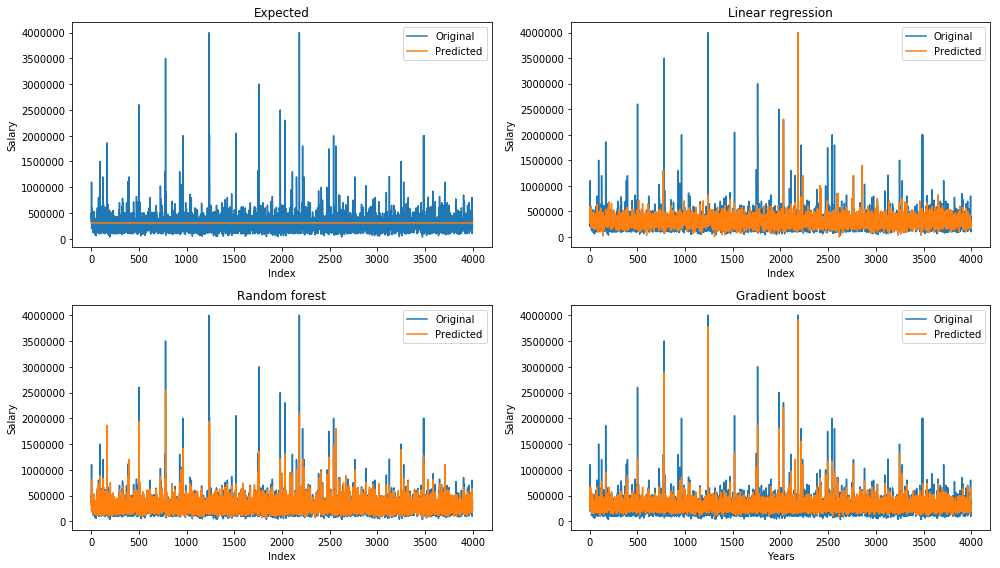

In [28]:
#Creating the subplot placeholders
fig, axes = plt.subplots(2, 2)
fig.set_figwidth(14)
fig.set_figheight(8)

#4 month MA
axes[0][0].plot(expected.Serial, expected.actual, label='Original')
axes[0][0].plot(expected.Serial, expected.predicted, label='Predicted')
axes[0][0].set_xlabel("Index")
axes[0][0].set_ylabel("Salary")
axes[0][0].set_title("Expected")
axes[0][0].legend(loc='best')

#6 month MA
axes[0][1].plot(linear.Serial, linear.actual, label='Original')
axes[0][1].plot(linear.Serial, linear.predicted, label='Predicted')
axes[0][1].set_xlabel("Index")
axes[0][1].set_ylabel("Salary")
axes[0][1].set_title("Linear regression")
axes[0][1].legend(loc='best')

#8 month MA
axes[1][0].plot(random.Serial, random.actual, label='Original')
axes[1][0].plot(random.Serial, random.predicted, label='Predicted')
axes[1][0].set_xlabel("Index")
axes[1][0].set_ylabel("Salary")
axes[1][0].set_title("Random forest")
axes[1][0].legend(loc='best')

#12 month MA
axes[1][1].plot(grad.Serial, grad.actual, label='Original')
axes[1][1].plot(grad.Serial, grad.predicted, label='Predicted')
axes[1][1].set_xlabel("Years")
axes[1][1].set_ylabel("Salary")
axes[1][1].set_title("Gradient boost")
axes[1][1].legend(loc='best')

plt.tight_layout()
plt.show()


# Deployment

In [39]:
base_rf.fit(new_x,y)
ypred_base_rf=base_rf.predict(new_x)
base_rf.feature_importances_

array([1.28995068e-01, 3.84553643e-02, 1.76760917e-02, 3.40536812e-02,
       1.65902134e-02, 6.57822944e-03, 2.34096756e-02, 1.28775435e-02,
       1.64153409e-03, 1.34422167e-02, 5.77912270e-02, 4.63265605e-02,
       1.07566982e-01, 2.57472850e-02, 3.39883898e-02, 3.58854472e-03,
       8.71952201e-03, 7.89624240e-03, 9.16094762e-04, 2.71267621e-03,
       2.10376156e-03, 1.45068331e-02, 1.41434092e-02, 1.38164249e-02,
       2.05156827e-02, 2.79867226e-02, 8.29911537e-04, 5.46309567e-04,
       8.20095408e-03, 0.00000000e+00, 0.00000000e+00, 7.81159492e-03,
       3.40511603e-08, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.91968379e-07,
       1.70600175e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.80488022e-07, 0.00000000e+00, 0.00000000e+00,
       4.47928670e-06, 3.08082591e-06, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 8.71126122e-05, 0.00000000e+00,
      

In [49]:
parameters=pd.DataFrame()
parameters['Features']=new_x.columns
parameters['Contribution']=base_rf.feature_importances_*100
parameters[parameters.Contribution>10]

,Features,Contribution
0,Experience,12.899507
12,Quant,10.756698


In [50]:
parameters[(parameters.Contribution<10)&(parameters.Contribution>=5)]

,Features,Contribution
10,English,5.779123
621,12board_up bord,9.654527


In [51]:
parameters[(parameters.Contribution<5)&(parameters.Contribution>=3)]

,Features,Contribution
1,10percentage,3.845536
3,12percentage,3.405368
11,Logical,4.632656
14,ComputerProgramming,3.398839
